In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image


In [38]:
class JPGFolderDataset(Dataset):
    def __init__(self, root, transform=None, recursive=True):
        self.root = Path(root)
        self.transform = transform
        pattern = "**/*.jpg" if recursive else "*.jpg"
        # Only JPGs; add *.jpeg if you want those too
        self.files = sorted(self.root.glob(pattern))

        if not self.files:
            raise FileNotFoundError(f"No .jpg files found under: {self.root.resolve()}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        # Return a dummy label (0) since there are no classes
        return img, 0


In [48]:
data_dir = r"../../../Github_datasets/Weapon_cctv/Weapons-in-Images/Weapons-in-Images"


dataset = JPGFolderDataset(data_dir, transform=None, recursive=True)

target_to_class = {v: k for k in ImageFolder(dataset).class_to_idx.items()}

TypeError: scandir: path should be string, bytes, os.PathLike or None, not JPGFolderDataset

In [40]:
len(dataset)

4375

In [42]:
dataset[5]

(<PIL.Image.Image image mode=RGB size=1024x683>, 0)

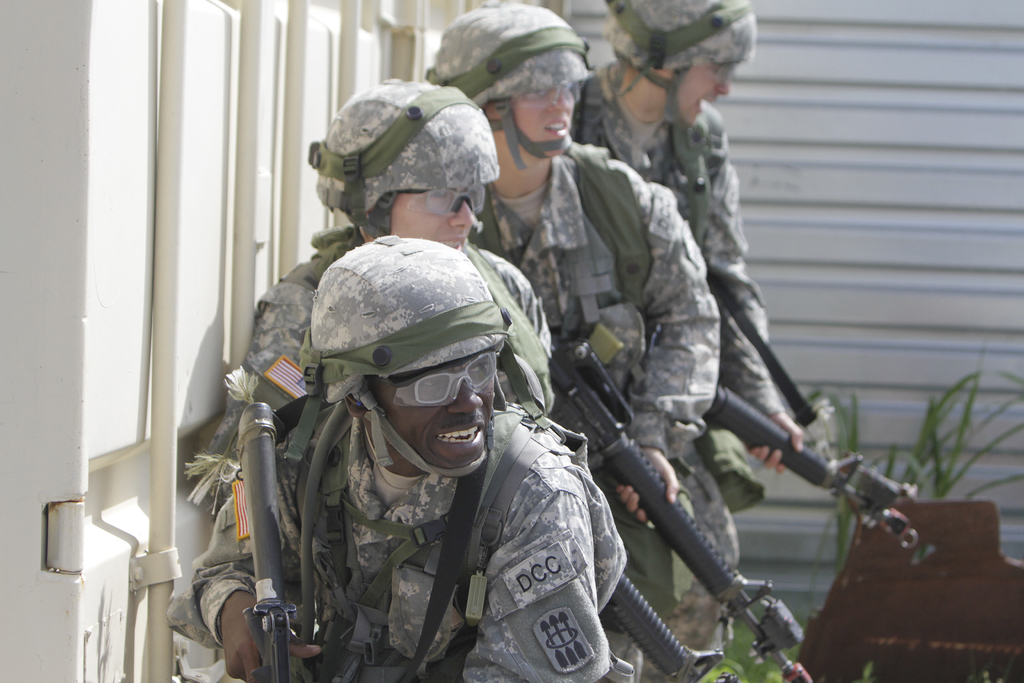

In [46]:
image, label = dataset[2000]
image